# Q-Learning from Scratch 🤖

## 🤖 Theoretical Background
Q-Learning is a model-free, off-policy reinforcement learning algorithm used to find the optimal action-selection policy for any given Markov Decision Process (MDP).
- **Q-Value**: The expected future reward for taking an action in a specific state.
- **Bellman Equation**: $Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma \max_{a'} Q(s', a') - Q(s, a)]$.
- **Exploration vs. Exploitation**: Using an epsilon-greedy strategy to balance trying new actions and using known good ones.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:

class GridWorld:
    def __init__(self):
        self.state = 0
    def reset(self):
        self.state = 0
        return self.state
    def step(self, action):
        row, col = divmod(self.state, 4)
        if action == 0: row = max(0, row - 1)    # Up
        elif action == 1: row = min(3, row + 1) # Down
        elif action == 2: col = max(0, col - 1) # Left
        elif action == 3: col = min(3, col + 1) # Right
        self.state = row * 4 + col
        reward = 1 if self.state == 15 else 0
        done = self.state == 15
        return self.state, reward, done


In [3]:

# Q-Learning Algorithm
n_states = 16
n_actions = 4

def train_q_learning(episodes=500, alpha=0.1, gamma=0.99, epsilon=0.1):
    env = GridWorld()
    Q = np.zeros((n_states, n_actions))
    rewards_history = []
    
    for _ in range(episodes):
        state = env.reset()
        total_reward = 0
        done = False
        while not done:
            # Epsilon-greedy
            if np.random.rand() < epsilon:
                action = np.random.randint(n_actions)
            else:
                action = np.argmax(Q[state])
            
            next_state, reward, done = env.step(action)
            
            # Update Q-table
            best_next_action = np.argmax(Q[next_state])
            td_target = reward + gamma * Q[next_state][best_next_action]
            Q[state][action] += alpha * (td_target - Q[state][action])
            
            state = next_state
            total_reward += reward
        rewards_history.append(total_reward)
    return Q, rewards_history

Q_table, q_rewards = train_q_learning()


### 📊 Visualization: Q-Table & Rewards

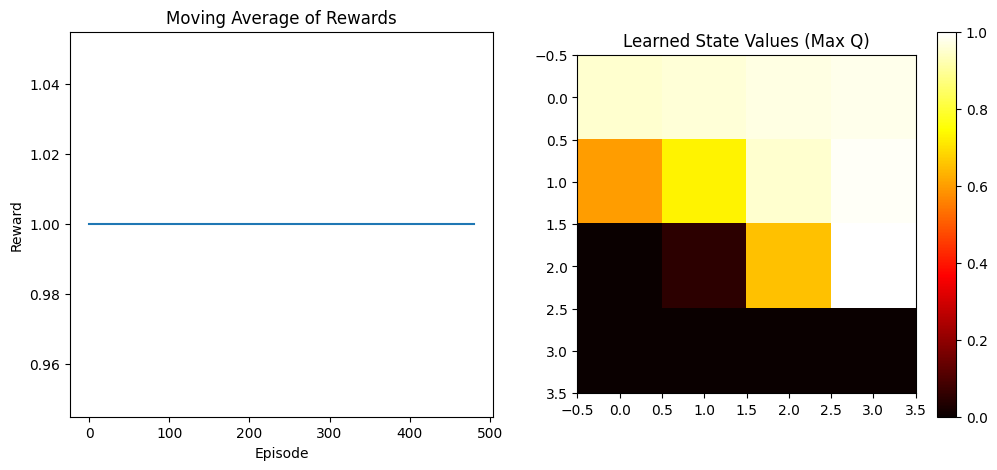

In [4]:

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(np.convolve(q_rewards, np.ones(20)/20, mode='valid'))
plt.title('Moving Average of Rewards')
plt.xlabel('Episode')
plt.ylabel('Reward')

plt.subplot(1, 2, 2)
plt.imshow(np.max(Q_table, axis=1).reshape(4, 4), cmap='hot')
plt.title('Learned State Values (Max Q)')
plt.colorbar()
plt.show()
